# Vocabulary Richness Analysis

This notebook implements the analysis described in `analysis_plan.md`.
Its purpose is not only to compute summary statistics and create figures, but also to explain clearly what each analysis step means, why it matters, and how the outputs should be interpreted.

The main focus is estimator behavior on real corpora. Domain comparison is included as a secondary descriptive analysis, but it is not the central research question.

Because the corpora do not provide a known ground-truth total vocabulary size, this notebook emphasizes descriptive comparison, estimator agreement, coverage, and frequency-spectrum interpretation rather than true error metrics such as RMSE or MAE.

## Notebook Roadmap

The notebook is organized as a coherent analysis narrative:

1. Load and validate the processed database.
2. Build an analysis-ready table combining corpus metadata and frequency-spectrum summaries.
3. Describe the retained data and its sample-size structure.
4. Compare richness estimators as a function of token count.
5. Contrast observed vocabulary and estimated total richness.
6. Relate estimator behavior to low-frequency counts such as `f_1` through `f_5`.
7. Interpret the estimates through sample coverage.
8. Study estimator agreement and disagreement directly.
9. Add a secondary domain-level comparison.
10. Summarize real-data behavior in descriptive tables.

Every figure is accompanied by markdown that explains what it shows and what to look for when interpreting it. After running the notebook, these interpretation notes should be updated with result-specific observations.

In [1]:
from pathlib import Path
import sqlite3
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import seaborn as sns
    HAVE_SEABORN = True
except ImportError:
    HAVE_SEABORN = False

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == "analysis" and NOTEBOOK_DIR.parent.name == "code":
    CODE_DIR = NOTEBOOK_DIR.parent
elif NOTEBOOK_DIR.name == "code":
    CODE_DIR = NOTEBOOK_DIR
else:
    CODE_DIR = NOTEBOOK_DIR / "code"

REPO_ROOT = CODE_DIR.parent
DATA_DIR = REPO_ROOT / "data"
DB_PATH = DATA_DIR / "processed.db"

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from estimators.classical import ace, chao1, ichao1, jackknife1, jackknife2
from estimators.coverage import coverage_chao_jost, coverage_turing

try:
    from estimators.breakaway import breakaway
    HAVE_BREAKAWAY = True
except Exception as exc:
    HAVE_BREAKAWAY = False
    BREAKAWAY_IMPORT_ERROR = exc

if HAVE_SEABORN:
    sns.set_theme(style="whitegrid", context="talk")
else:
    plt.style.use("ggplot")

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 200)

DB_PATH

WindowsPath('C:/Users/frato/OneDrive/Documents/ETH/Semester6/BachelorThesis/data/processed.db')

## 1. Load The Database

The first step is to load the processed SQLite database and inspect the tables needed for the analysis.

The core tables used here are:

- `corpora`, which stores metadata and summary quantities for each processed text or speaker
- `freq_counts`, which stores the frequency spectrum `f_k` for low values of `k`

The notebook uses these tables to reconstruct the low-frequency spectrum, compute estimator outputs, and relate those outputs to sample size, coverage, and rare-word behavior.

In [2]:
if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

conn = sqlite3.connect(DB_PATH)

corpora = pd.read_sql_query("SELECT * FROM corpora", conn)
freq_counts = pd.read_sql_query("SELECT * FROM freq_counts", conn)

print(f"Loaded {len(corpora):,} corpus rows from {DB_PATH.name}.")
print(f"Loaded {len(freq_counts):,} frequency-spectrum rows.")
if not HAVE_BREAKAWAY:
    warnings.warn(f"Breakaway could not be imported and will be skipped: {BREAKAWAY_IMPORT_ERROR}")

display(corpora.head())
display(freq_counts.head())

Loaded 5,603 corpus rows from processed.db.
Loaded 86,459 frequency-spectrum rows.


,id,name,source_path,loader,n_tokens,s_obs,coverage_turing,coverage_chao_jost,source_mtime,processed_at,corpus_source,speaker_id
0,1,full_corpus,data\shakespeare-dataset-main\text,corpus,890426,25700,0.989102,0.989102,1.776298e+09,2026-04-16T00:30:42.354712+00:00,NaN,NaN
1,3,A Midsummer Nights Dream,..\..\data\shakespeare-dataset-main\text\a-mid...,shakespeare,16385,2974,0.897650,0.897654,1.776298e+09,2026-04-16T00:31:58.556092+00:00,NaN,NaN
2,4,Alls Well That Ends Well,..\..\data\shakespeare-dataset-main\text\alls-...,shakespeare,22852,3477,0.912699,0.912701,1.776298e+09,2026-04-16T00:31:58.643732+00:00,NaN,NaN
3,5,Antony And Cleopatra,..\..\data\shakespeare-dataset-main\text\anton...,shakespeare,24147,3882,0.906075,0.906077,1.776298e+09,2026-04-16T00:31:58.731991+00:00,NaN,NaN
4,6,As You Like It,..\..\data\shakespeare-dataset-main\text\as-yo...,shakespeare,21554,3229,0.917185,0.917187,1.776298e+09,2026-04-16T00:31:58.802908+00:00,NaN,NaN


,corpus_id,k,f_k
0,1,1,9704
1,1,2,3562
2,1,3,2050
3,1,4,1408
4,1,5,1028


## 2. Build An Analysis-Ready Table

The metadata table alone is not enough for the planned analysis because estimator behavior depends strongly on the low-frequency spectrum.

This step expands the database into a single analysis table containing:

- corpus-level metadata such as token count and observed vocabulary size
- low-frequency counts such as `f_1`, `f_2`, ..., `f_5`
- grouped rare-frequency summaries
- normalized singleton and rare-word measures

These derived features provide the bridge between raw corpus summaries and the estimation behavior studied later in the notebook.

In [3]:
freq_wide = (
    freq_counts.pivot_table(index="corpus_id", columns="k", values="f_k", fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)

analysis_df = corpora.merge(freq_wide, how="left", left_on="id", right_on="corpus_id")
analysis_df = analysis_df.drop(columns=["corpus_id"], errors="ignore")

for k in range(1, 21):
    if k not in analysis_df.columns:
        analysis_df[k] = 0
    analysis_df[k] = analysis_df[k].fillna(0).astype(int)

analysis_df["rare_1_5"] = analysis_df[[1, 2, 3, 4, 5]].sum(axis=1)
analysis_df["rare_1_10"] = analysis_df[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]].sum(axis=1)
analysis_df["singleton_rate"] = analysis_df[1] / analysis_df["n_tokens"].replace(0, np.nan)
analysis_df["singleton_share_obs"] = analysis_df[1] / analysis_df["s_obs"].replace(0, np.nan)
analysis_df["rare_1_5_share_obs"] = analysis_df["rare_1_5"] / analysis_df["s_obs"].replace(0, np.nan)
analysis_df["type_token_ratio"] = analysis_df["s_obs"] / analysis_df["n_tokens"].replace(0, np.nan)
analysis_df["corpus_source"] = analysis_df["corpus_source"].fillna("unknown")

def freq_dict_for(corpus_id: int) -> dict[int, int]:
    rows = freq_counts.loc[freq_counts["corpus_id"] == corpus_id, ["k", "f_k"]]
    return {int(k): int(f_k) for k, f_k in rows.itertuples(index=False, name=None)}

analysis_df["freq_dict"] = analysis_df["id"].map(freq_dict_for)
analysis_df.head()

,id,name,source_path,loader,n_tokens,s_obs,coverage_turing,coverage_chao_jost,source_mtime,processed_at,corpus_source,speaker_id,1,2,3,4,5,6,7,8,9,10,11,12,13,...,7100,7295,7357,8093,8110,8196,8986,9818,11700,11739,13083,14642,14988,17383,20131,21647,26961,28170,rare_1_5,rare_1_10,singleton_rate,singleton_share_obs,rare_1_5_share_obs,type_token_ratio,freq_dict
0,1,full_corpus,data\shakespeare-dataset-main\text,corpus,890426,25700,0.989102,0.989102,1.776298e+09,2026-04-16T00:30:42.354712+00:00,unknown,NaN,9704,3562,2050,1408,1028,759,620,475,415,393,292,264,217,...,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,17752,20414,0.010898,0.377588,0.690739,0.028863,"{1: 9704, 2: 3562, 3: 2050, 4: 1408, 5: 1028, ..."
1,3,A Midsummer Nights Dream,..\..\data\shakespeare-dataset-main\text\a-mid...,shakespeare,16385,2974,0.897650,0.897654,1.776298e+09,2026-04-16T00:31:58.556092+00:00,unknown,NaN,1677,467,219,141,81,63,40,30,36,21,15,10,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2585,2775,0.102350,0.563887,0.869200,0.181507,"{1: 1677, 2: 467, 3: 219, 4: 141, 5: 81, 6: 63..."
2,4,Alls Well That Ends Well,..\..\data\shakespeare-dataset-main\text\alls-...,shakespeare,22852,3477,0.912699,0.912701,1.776298e+09,2026-04-16T00:31:58.643732+00:00,unknown,NaN,1995,501,254,130,91,83,52,38,28,21,21,16,13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2971,3193,0.087301,0.573770,0.854472,0.152153,"{1: 1995, 2: 501, 3: 254, 4: 130, 5: 91, 6: 83..."
3,5,Antony And Cleopatra,..\..\data\shakespeare-dataset-main\text\anton...,shakespeare,24147,3882,0.906075,0.906077,1.776298e+09,2026-04-16T00:31:58.731991+00:00,unknown,NaN,2268,577,265,141,106,70,54,39,33,29,24,13,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3357,3582,0.093925,0.584235,0.864760,0.160765,"{1: 2268, 2: 577, 3: 265, 4: 141, 5: 106, 6: 7..."
4,6,As You Like It,..\..\data\shakespeare-dataset-main\text\as-yo...,shakespeare,21554,3229,0.917185,0.917187,1.776298e+09,2026-04-16T00:31:58.802908+00:00,unknown,NaN,1785,495,266,142,85,71,34,29,37,23,18,22,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2773,2967,0.082815,0.552803,0.858780,0.149810,"{1: 1785, 2: 495, 3: 266, 4: 142, 5: 85, 6: 71..."


## 3. Data Overview

This section describes the retained empirical sample before any estimator comparison is made.

The main questions are:

- How many texts or speakers are available per corpus?
- How large are the samples in token-count terms?
- How much observed vocabulary is already present before any extrapolation?

These summaries matter because estimator behavior is heavily shaped by the distribution of sample sizes. If one corpus contains many small samples and another contains mostly larger samples, naive comparisons can be misleading.

In [4]:
corpus_overview = (
    analysis_df.groupby("corpus_source")
    .agg(
        n_texts=("id", "size"),
        min_tokens=("n_tokens", "min"),
        median_tokens=("n_tokens", "median"),
        mean_tokens=("n_tokens", "mean"),
        max_tokens=("n_tokens", "max"),
        min_s_obs=("s_obs", "min"),
        median_s_obs=("s_obs", "median"),
        mean_s_obs=("s_obs", "mean"),
        max_s_obs=("s_obs", "max")
    )
    .sort_values("n_texts", ascending=False)
)
display(corpus_overview)
display(analysis_df[["id", "name", "corpus_source", "speaker_id", "n_tokens", "s_obs", "coverage_turing", "coverage_chao_jost"]].head())

,n_texts,min_tokens,median_tokens,mean_tokens,max_tokens,min_s_obs,median_s_obs,mean_s_obs,max_s_obs
corpus_source,,,,,,,,,
imsdb,5335,61,814.0,1182.340394,9529,1,357.0,431.578444,2171
bnc,136,2,692.0,2296.139706,36869,2,282.5,411.889706,2643
sbcorpus,46,1,1156.5,1202.217391,5311,1,404.0,338.239130,1072
unknown,44,362,21550.5,41157.886364,890426,221,3563.0,3977.886364,25700
shakespeare,42,362,21473.0,21200.619048,30095,221,3550.5,3444.261905,4668


,id,name,corpus_source,speaker_id,n_tokens,s_obs,coverage_turing,coverage_chao_jost
0,1,full_corpus,unknown,NaN,890426,25700,0.989102,0.989102
1,3,A Midsummer Nights Dream,unknown,NaN,16385,2974,0.897650,0.897654
2,4,Alls Well That Ends Well,unknown,NaN,22852,3477,0.912699,0.912701
3,5,Antony And Cleopatra,unknown,NaN,24147,3882,0.906075,0.906077
4,6,As You Like It,unknown,NaN,21554,3229,0.917185,0.917187


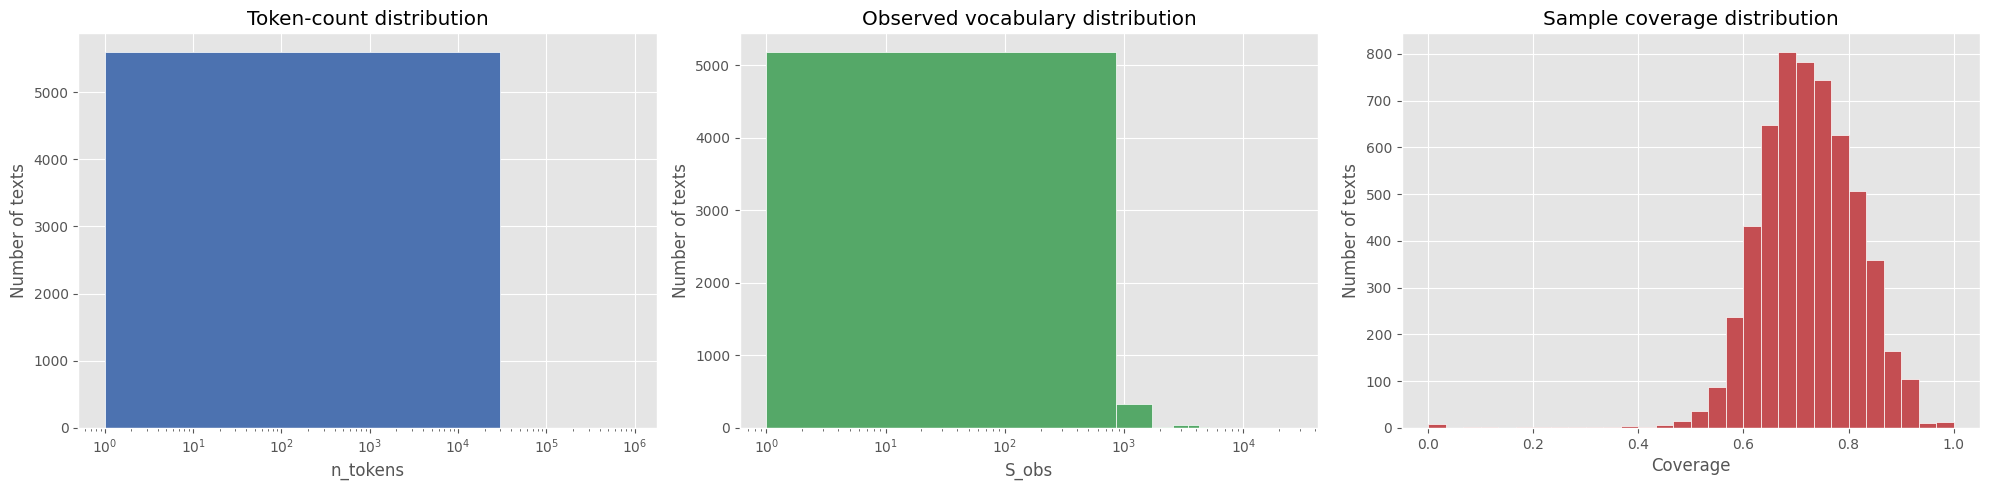

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(analysis_df["n_tokens"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Token-count distribution")
axes[0].set_xlabel("n_tokens")
axes[0].set_ylabel("Number of texts")
axes[0].set_xscale("log")

axes[1].hist(analysis_df["s_obs"], bins=30, color="#55A868", edgecolor="white")
axes[1].set_title("Observed vocabulary distribution")
axes[1].set_xlabel("S_obs")
axes[1].set_ylabel("Number of texts")
axes[1].set_xscale("log")

axes[2].hist(analysis_df["coverage_chao_jost"].dropna(), bins=30, color="#C44E52", edgecolor="white")
axes[2].set_title("Sample coverage distribution")
axes[2].set_xlabel("Coverage")
axes[2].set_ylabel("Number of texts")

plt.tight_layout()
plt.show()

**Figure explanation.**

These three panels summarize the empirical scale of the retained data. The token-count histogram shows how much sample-size heterogeneity exists in the corpus collection. The observed-vocabulary histogram shows how large the directly observed lexicons are before extrapolation. The coverage histogram indicates how complete the samples appear to be under a coverage-based perspective.

When interpreting this figure, pay attention to whether the data are concentrated in a narrow sample-size band or spread across a wide range. A wide range means that sample-size control is essential in later sections. Also note whether the coverage values cluster near one or whether many texts appear incomplete; that distinction strongly influences how much unseen vocabulary the estimators are likely to infer.

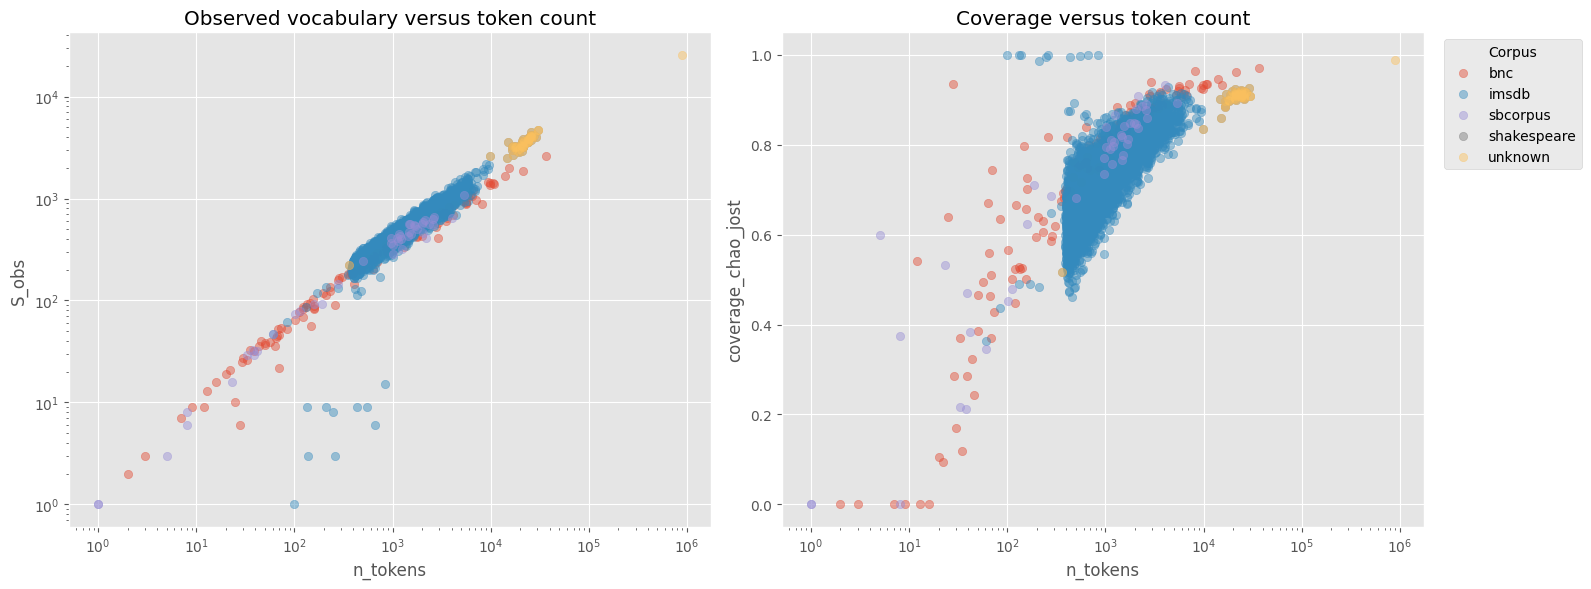

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for corpus_name, group in analysis_df.groupby("corpus_source"):
    axes[0].scatter(group["n_tokens"], group["s_obs"], alpha=0.45, label=corpus_name)
    axes[1].scatter(group["n_tokens"], group["coverage_chao_jost"], alpha=0.45, label=corpus_name)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Observed vocabulary versus token count")
axes[0].set_xlabel("n_tokens")
axes[0].set_ylabel("S_obs")

axes[1].set_xscale("log")
axes[1].set_title("Coverage versus token count")
axes[1].set_xlabel("n_tokens")
axes[1].set_ylabel("coverage_chao_jost")
axes[1].legend(title="Corpus", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Figure explanation.**

The left panel establishes the basic lexical-growth relationship that exists even before estimation. Observed vocabulary should increase with token count, but the spread around that relationship can already reveal heterogeneity in lexical diversity. The right panel shows how sample coverage changes with sample size and whether high-token texts also tend to look more complete.

In the interpretation, focus on whether the spread is narrow or wide at similar token counts. Wide spread suggests that meaningful diversity differences remain even after accounting for sample size. Also note whether coverage rises smoothly with sample size or whether many texts remain low-coverage even when they are not especially short.

## 4. Compute Richness Estimates

The notebook now applies the richness estimators available in the project to every retained text.

This transforms the low-frequency spectrum of each text into one or more estimated total-vocabulary values. The resulting table supports the core comparison between estimators and provides the basis for the later analyses of coverage, singleton counts, and estimator agreement.

Any failed estimator calls are recorded explicitly rather than hidden. This is important because numerical instability or undefined outputs are part of estimator behavior and should be documented.

In [7]:
estimator_specs = {
    "chao1": lambda f: chao1(f),
    "ichao1": lambda f: ichao1(f),
    "ace": lambda f: ace(f),
    "jackknife1": lambda f: jackknife1(f),
    "jackknife2": lambda f: jackknife2(f),
}

if HAVE_BREAKAWAY:
    estimator_specs["breakaway"] = lambda f: breakaway(f)["S_hat"]

estimate_rows = []
failure_rows = []

for row in analysis_df.itertuples(index=False):
    freq_dict = row.freq_dict
    for estimator_name, estimator_fn in estimator_specs.items():
        try:
            s_hat = float(estimator_fn(freq_dict))
            estimate_rows.append(
                {
                    "id": row.id,
                    "name": row.name,
                    "corpus_source": row.corpus_source,
                    "speaker_id": row.speaker_id,
                    "n_tokens": row.n_tokens,
                    "S_obs": row.s_obs,
                    "coverage_turing": row.coverage_turing,
                    "coverage_chao_jost": row.coverage_chao_jost,
                    "f1": freq_dict.get(1, 0),
                    "f2": freq_dict.get(2, 0),
                    "rare_1_5": row.rare_1_5,
                    "singleton_rate": row.singleton_rate,
                    "rare_1_5_share_obs": row.rare_1_5_share_obs,
                    "estimator": estimator_name,
                    "S_hat": s_hat,
                    "f0_hat": s_hat - row.s_obs,
                    "richness_ratio": s_hat / row.s_obs if row.s_obs else np.nan,
                }
            )
        except Exception as exc:
            failure_rows.append(
                {
                    "id": row.id,
                    "name": row.name,
                    "corpus_source": row.corpus_source,
                    "estimator": estimator_name,
                    "error": str(exc),
                }
            )

estimates_long = pd.DataFrame(estimate_rows)
failures = pd.DataFrame(failure_rows)
estimates_wide = estimates_long.pivot_table(index="id", columns="estimator", values="S_hat")

print(f"Computed {len(estimates_long):,} estimator outputs.")
print(f"Recorded {len(failures):,} failed estimator calls.")
display(estimates_long.head())
if not failures.empty:
    display(failures.groupby("estimator").size().rename("n_failures").sort_values(ascending=False))

Computed 30,783 estimator outputs.
Recorded 2,835 failed estimator calls.


,id,name,corpus_source,speaker_id,n_tokens,S_obs,coverage_turing,coverage_chao_jost,f1,f2,rare_1_5,singleton_rate,rare_1_5_share_obs,estimator,S_hat,f0_hat,richness_ratio
0,1,full_corpus,unknown,NaN,890426,25700,0.989102,0.989102,9704,3562,17752,0.010898,0.690739,chao1,38918.347873,13218.347873,1.514333
1,1,full_corpus,unknown,NaN,890426,25700,0.989102,0.989102,9704,3562,17752,0.010898,0.690739,ichao1,41506.657264,15806.657264,1.615045
2,1,full_corpus,unknown,NaN,890426,25700,0.989102,0.989102,9704,3562,17752,0.010898,0.690739,ace,70942.206726,45242.206726,2.760397
3,1,full_corpus,unknown,NaN,890426,25700,0.989102,0.989102,9704,3562,17752,0.010898,0.690739,jackknife1,35403.989102,9703.989102,1.377587
4,1,full_corpus,unknown,NaN,890426,25700,0.989102,0.989102,9704,3562,17752,0.010898,0.690739,jackknife2,41545.979307,15845.979307,1.616575


estimator
breakaway     2821
jackknife2       5
chao1            3
ichao1           3
jackknife1       3
Name: n_failures, dtype: int64

**Estimator-output explanation.**

The long-format estimates table is the main working dataset for the rest of the notebook. Each row corresponds to one corpus item and one estimator, making it easy to compare methods on the same text and to reshape the data for plotting.

If the failure table is non-empty, those failures should not be treated as an inconvenience to ignore. They are part of the substantive estimator comparison, especially if one method fails disproportionately on sparse or low-coverage data.

## 5. Main Comparison: Estimated Richness Versus Sample Size

This is the central section of the notebook. The goal is to study how estimated total vocabulary richness varies with sample size and whether different estimators react differently to the same token-count range.

The comparison is shown in two complementary ways:

- a raw scatter view that preserves individual-level variation
- a binned-average view that highlights broad estimator trends

These two views should always be interpreted together. Raw scatter reveals heterogeneity; binned curves reveal the overall estimator response to sample size.

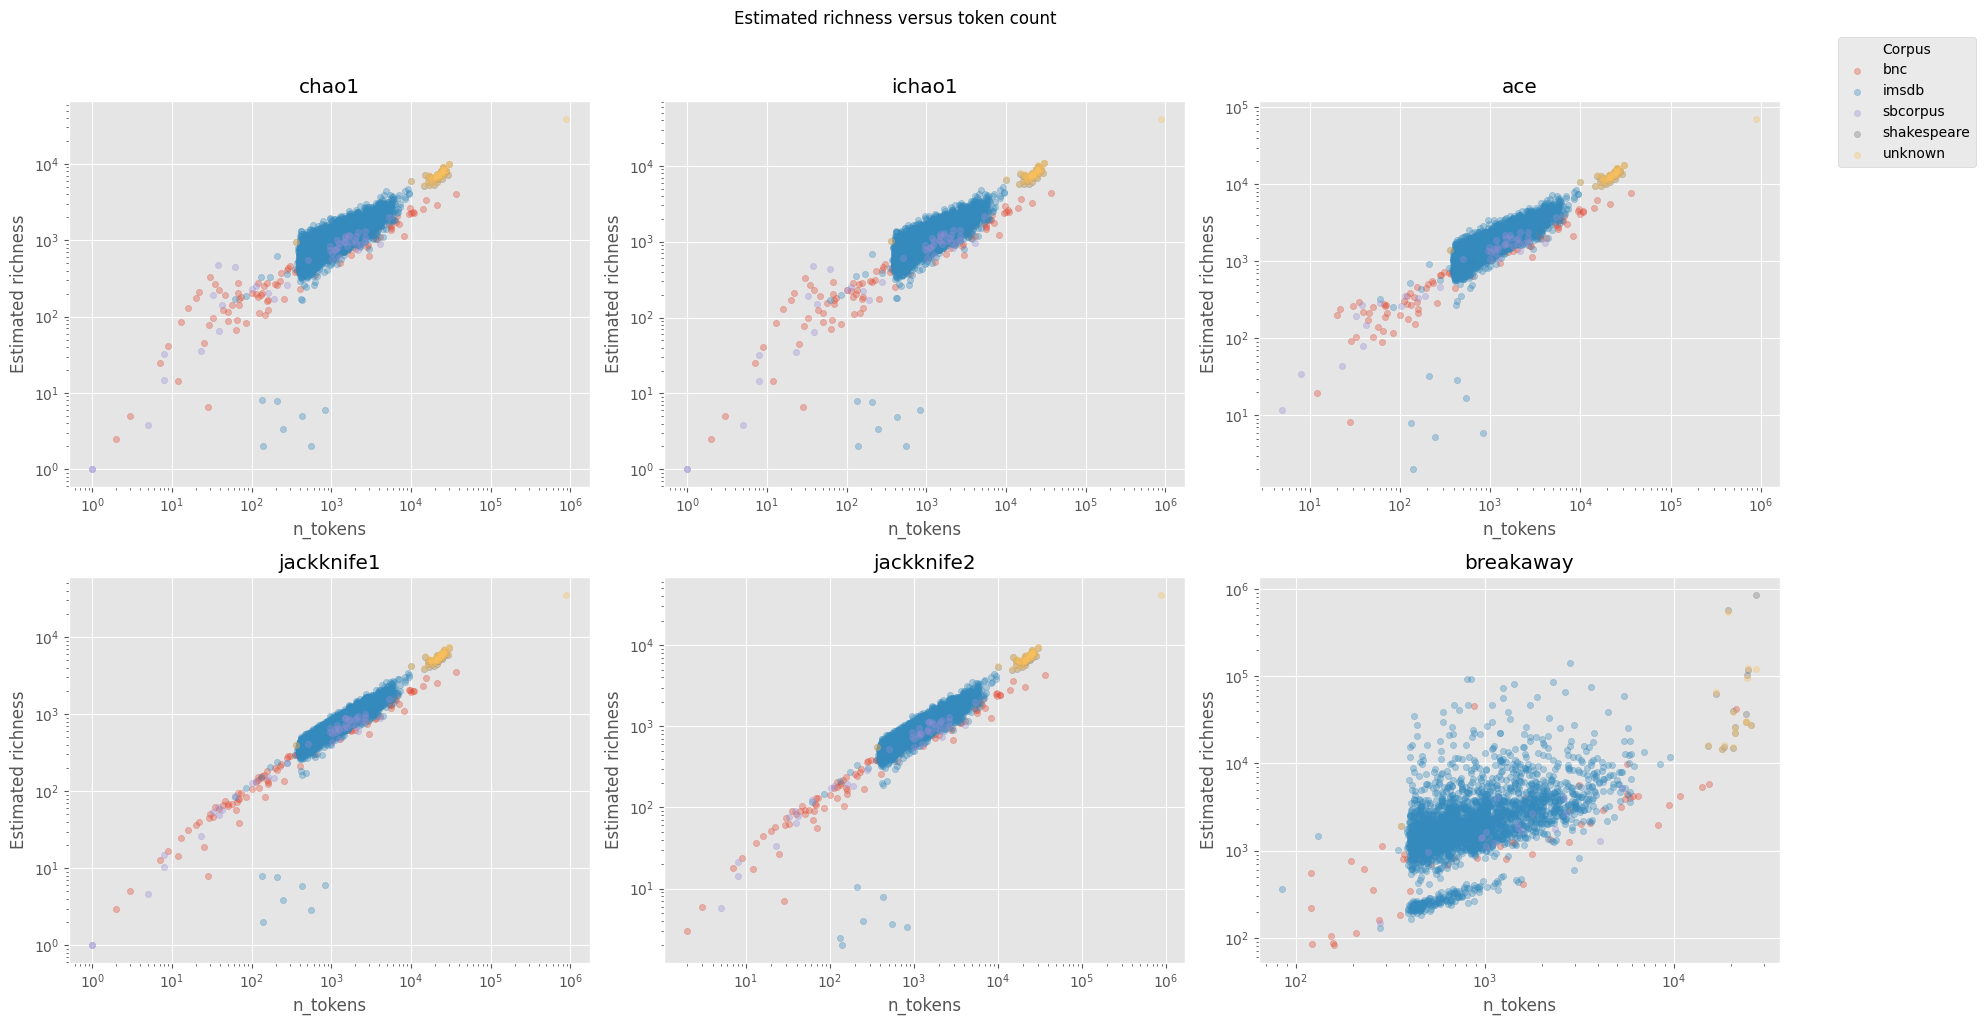

In [8]:
estimators = list(estimates_long["estimator"].drop_duplicates())
n_cols = 3
n_rows = int(np.ceil(len(estimators) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), squeeze=False)

for ax, estimator_name in zip(axes.ravel(), estimators):
    subset = estimates_long.loc[estimates_long["estimator"] == estimator_name]
    for corpus_name, group in subset.groupby("corpus_source"):
        ax.scatter(group["n_tokens"], group["S_hat"], alpha=0.35, s=20, label=corpus_name)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(estimator_name)
    ax.set_xlabel("n_tokens")
    ax.set_ylabel("Estimated richness")

for ax in axes.ravel()[len(estimators):]:
    ax.axis("off")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Corpus", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Estimated richness versus token count", y=1.02)
plt.tight_layout()
plt.show()

**Figure explanation.**

Each panel shows one estimator applied to the full collection of texts. The x-axis is token count, and the y-axis is estimated total vocabulary richness. Both axes are on a log scale because the data can vary over wide ranges and because multiplicative differences are often easier to interpret than additive differences.

Focus on three issues when interpreting the result: whether the estimator increases smoothly with sample size, whether there is substantial vertical spread at similar token counts, and whether different corpora appear to occupy distinct regions of the panel. A smooth pattern suggests stable scaling; a highly diffuse pattern suggests strong heterogeneity or instability.

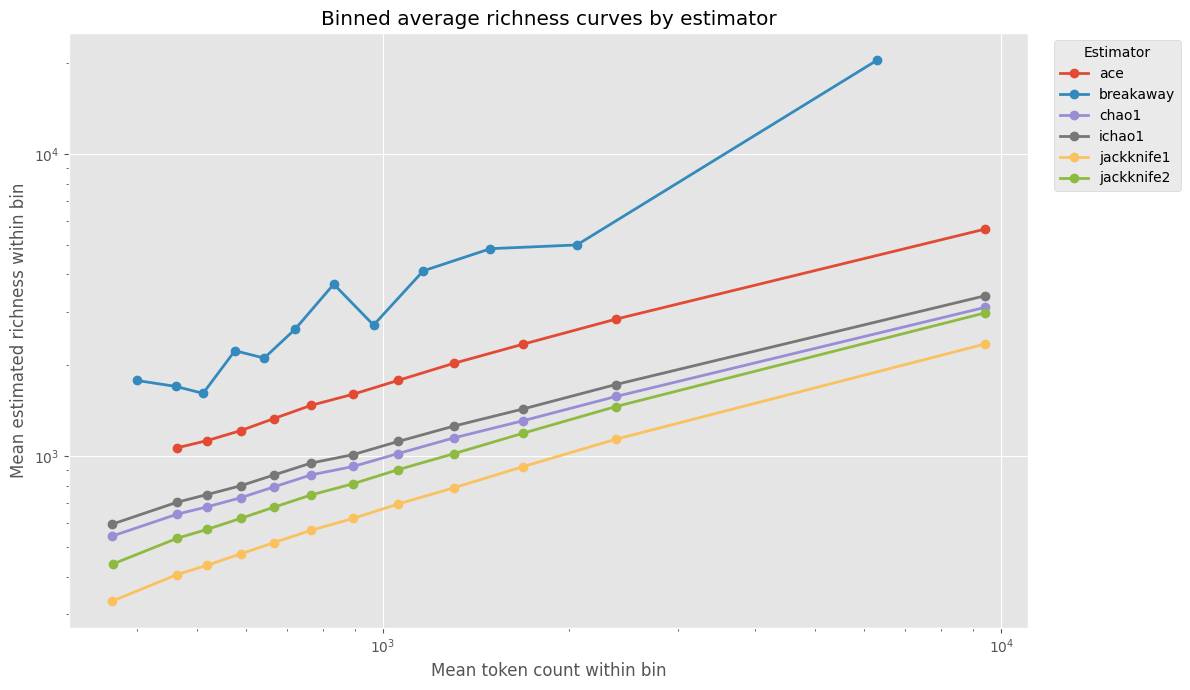

In [9]:
def make_binned_curve(data: pd.DataFrame, n_bins: int = 12) -> pd.DataFrame:
    working = data[["n_tokens", "S_hat"]].dropna().copy()
    if working["n_tokens"].nunique() < 4:
        return pd.DataFrame(columns=["token_center", "mean_S_hat", "n_items"])
    working["bin"] = pd.qcut(working["n_tokens"], q=min(n_bins, working["n_tokens"].nunique()), duplicates="drop")
    return (
        working.groupby("bin", observed=False)
        .agg(token_center=("n_tokens", "mean"), mean_S_hat=("S_hat", "mean"), n_items=("S_hat", "size"))
        .reset_index(drop=True)
    )

fig, ax = plt.subplots(figsize=(12, 7))
for estimator_name, subset in estimates_long.groupby("estimator"):
    curve = make_binned_curve(subset)
    if not curve.empty:
        ax.plot(curve["token_center"], curve["mean_S_hat"], marker="o", linewidth=2, label=estimator_name)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Binned average richness curves by estimator")
ax.set_xlabel("Mean token count within bin")
ax.set_ylabel("Mean estimated richness within bin")
ax.legend(title="Estimator", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Figure explanation.**

This figure smooths the raw scatter by grouping nearby sample sizes and averaging the estimator outputs within those bins. It is useful for comparing the broad sample-size response of the estimators without letting individual outliers dominate the visual impression.

When interpreting these curves, pay attention to whether they remain roughly parallel or whether they diverge as token count grows. Parallel curves suggest stable estimator ordering across the sample-size range, while diverging curves suggest that estimator disagreement depends on the amount of available text.

## 6. Observed Versus Estimated Vocabulary

The previous section showed how the estimates scale with token count. This section asks a different question: how far do the estimators move beyond what is actually observed?

This matters because total richness estimates are meaningful only insofar as the extrapolation beyond `S_obs` is interpretable. An estimator that stays close to `S_obs` behaves conservatively; an estimator that infers a large unseen component behaves more aggressively.

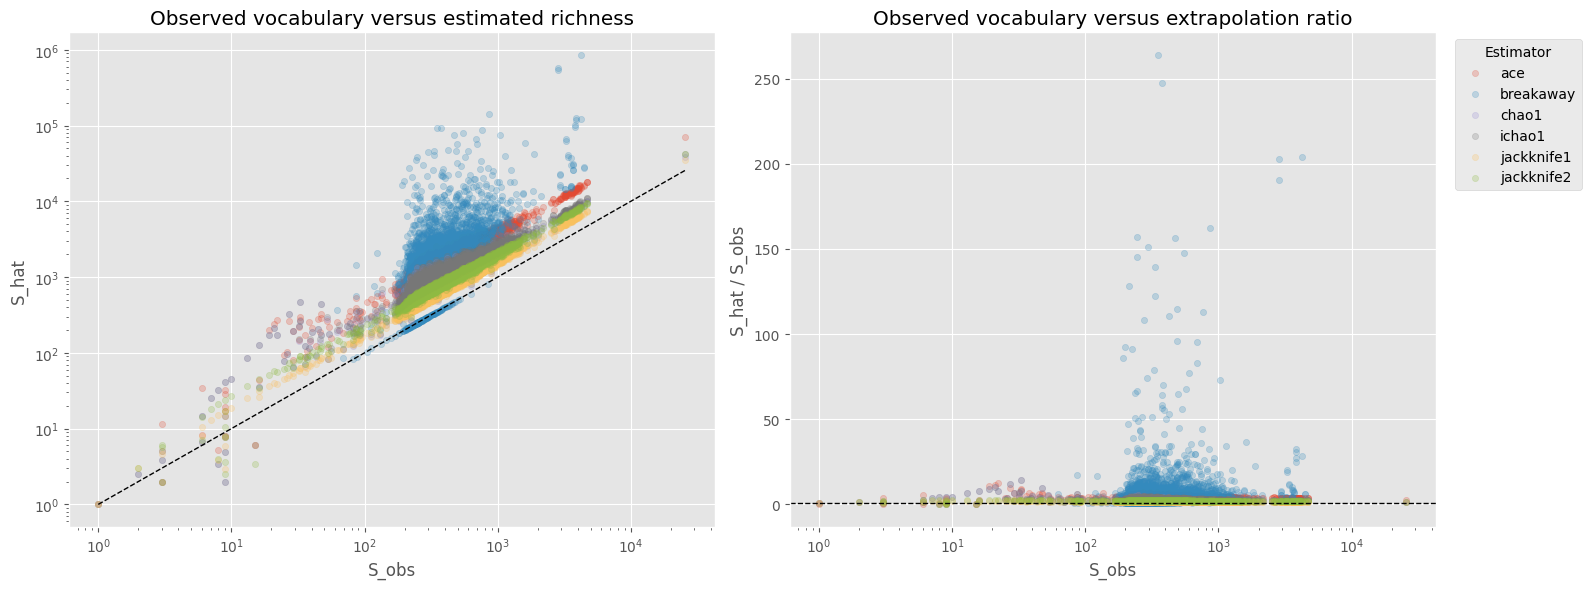

In [10]:
selected = estimates_long.copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for estimator_name, subset in selected.groupby("estimator"):
    axes[0].scatter(subset["S_obs"], subset["S_hat"], alpha=0.25, s=20, label=estimator_name)
    axes[1].scatter(subset["S_obs"], subset["richness_ratio"], alpha=0.25, s=20, label=estimator_name)

obs_min = selected["S_obs"].min()
obs_max = selected["S_obs"].max()
axes[0].plot([obs_min, obs_max], [obs_min, obs_max], linestyle="--", color="black", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Observed vocabulary versus estimated richness")
axes[0].set_xlabel("S_obs")
axes[0].set_ylabel("S_hat")

axes[1].set_xscale("log")
axes[1].set_title("Observed vocabulary versus extrapolation ratio")
axes[1].set_xlabel("S_obs")
axes[1].set_ylabel("S_hat / S_obs")
axes[1].axhline(1.0, linestyle="--", color="black", linewidth=1)
axes[1].legend(title="Estimator", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Figure explanation.**

The left panel compares directly observed vocabulary with total estimated richness. Points near the diagonal indicate limited extrapolation, whereas points well above the diagonal indicate that the estimator infers a substantial unseen component. The right panel expresses the same idea in ratio form, which is often easier to interpret across different scales of observed vocabulary.

A key question here is whether extrapolation shrinks for high-coverage or high-`S_obs` texts. If some methods continue to extrapolate strongly even when observed vocabulary is already large, those methods should be discussed carefully in the final interpretation.

## 7. Frequency Spectrum Analysis

This section links estimator behavior to the low-frequency spectrum, especially singleton counts. This is one of the most important interpretive parts of the notebook because richness estimators are often driven more by rare-word structure than by sample size alone.

The main idea is simple: the more singletons and near-singletons a text contains, the more evidence there is that many vocabulary types may remain unseen. The figures below show how that logic manifests empirically.

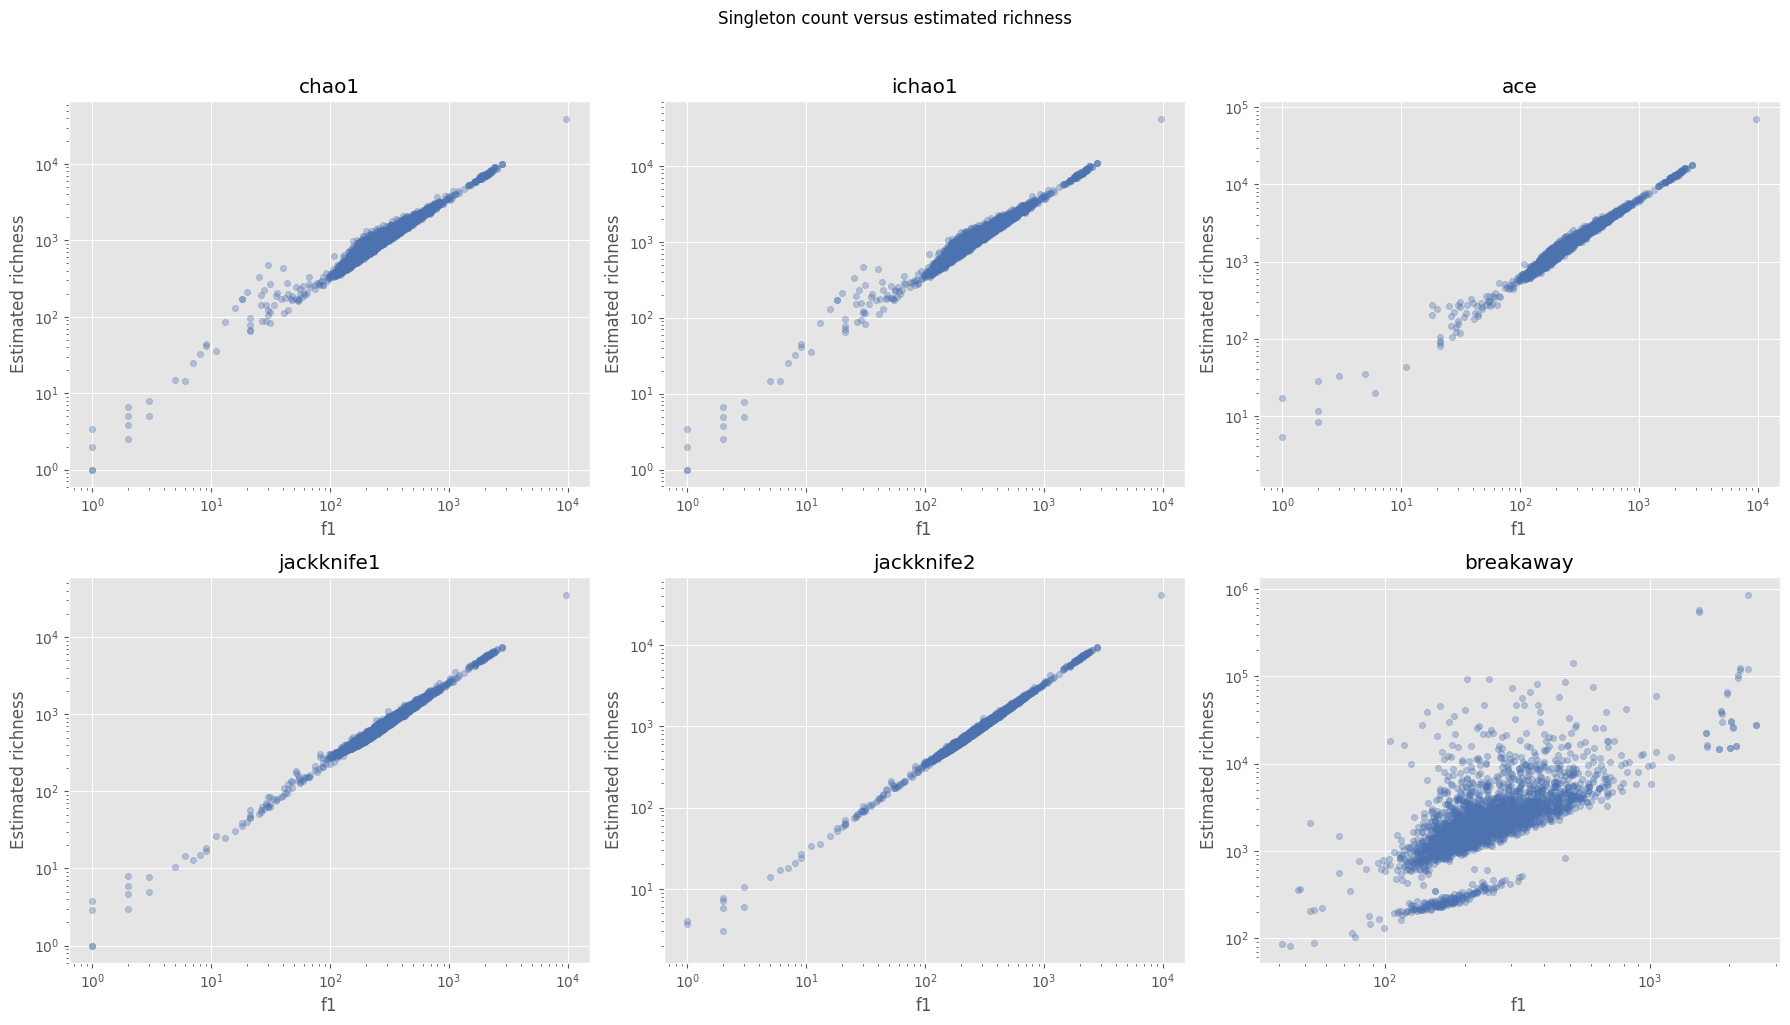

In [11]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), squeeze=False)

for ax, estimator_name in zip(axes.ravel(), estimators):
    subset = estimates_long.loc[estimates_long["estimator"] == estimator_name]
    ax.scatter(subset["f1"], subset["S_hat"], alpha=0.35, s=20, color="#4C72B0")
    ax.set_title(estimator_name)
    ax.set_xlabel("f1")
    ax.set_ylabel("Estimated richness")
    ax.set_xscale("log")
    ax.set_yscale("log")

for ax in axes.ravel()[len(estimators):]:
    ax.axis("off")

fig.suptitle("Singleton count versus estimated richness", y=1.02)
plt.tight_layout()
plt.show()

**Figure explanation.**

This figure isolates the relationship between singleton counts and estimated richness. Since many nonparametric richness estimators are driven heavily by `f_1`, the goal here is to show whether the empirical estimator outputs respond to singleton variation in the expected way.

Interpret this figure with caution because raw `f_1` is itself partly a function of sample size. A strong positive relationship is expected, but it does not automatically mean the estimator is capturing deeper richness structure. That is why the next figure uses normalized rare-word summaries.

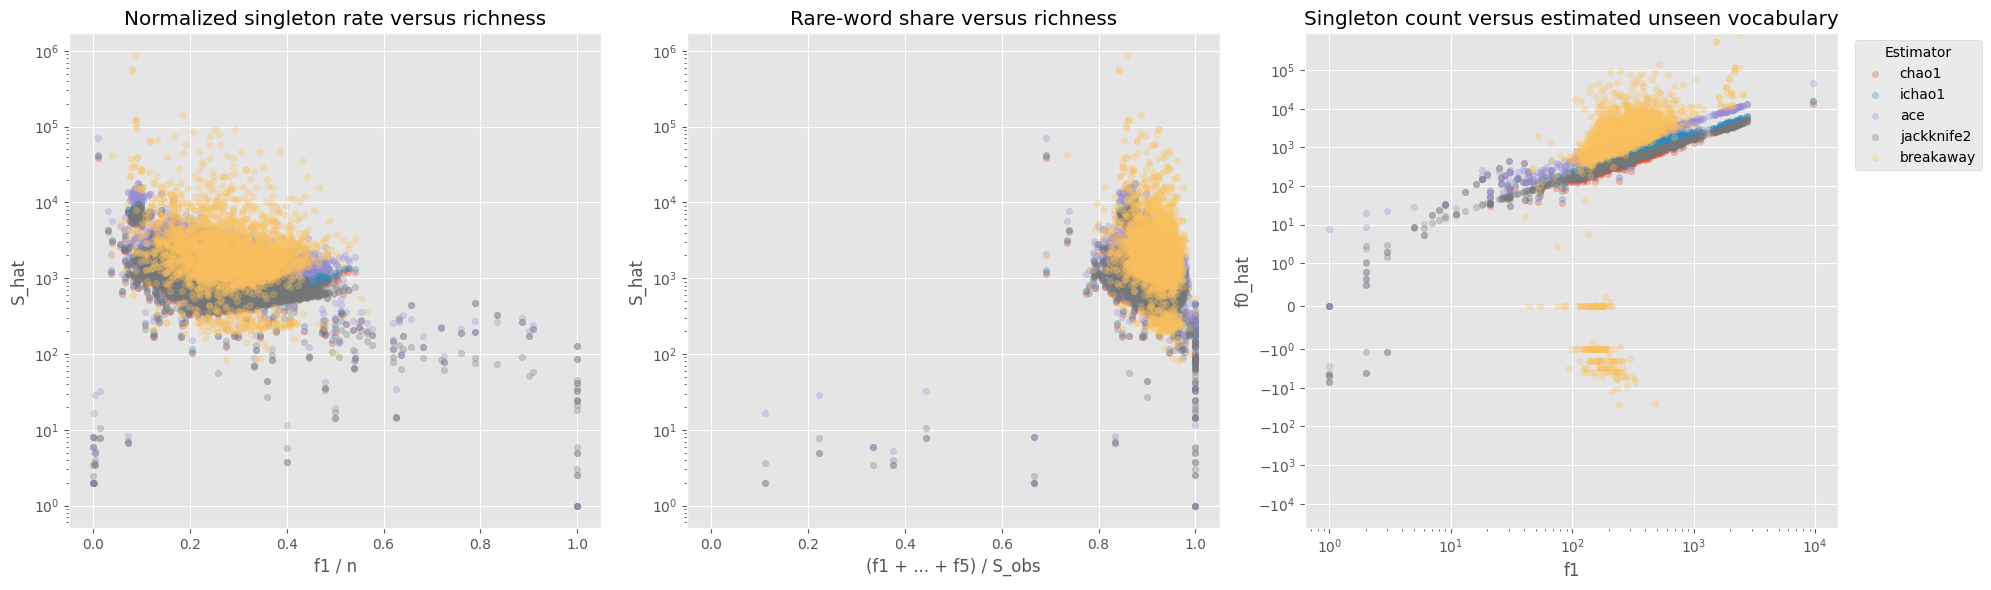

In [12]:
focus_estimators = [name for name in ["chao1", "ichao1", "ace", "jackknife2", "breakaway"] if name in estimators]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for estimator_name in focus_estimators:
    subset = estimates_long.loc[estimates_long["estimator"] == estimator_name]
    axes[0].scatter(subset["singleton_rate"], subset["S_hat"], alpha=0.3, s=20, label=estimator_name)
    axes[1].scatter(subset["rare_1_5_share_obs"], subset["S_hat"], alpha=0.3, s=20, label=estimator_name)
    axes[2].scatter(subset["f1"], subset["f0_hat"], alpha=0.3, s=20, label=estimator_name)

axes[0].set_title("Normalized singleton rate versus richness")
axes[0].set_xlabel("f1 / n")
axes[0].set_ylabel("S_hat")
axes[0].set_yscale("log")

axes[1].set_title("Rare-word share versus richness")
axes[1].set_xlabel("(f1 + ... + f5) / S_obs")
axes[1].set_ylabel("S_hat")
axes[1].set_yscale("log")

axes[2].set_title("Singleton count versus estimated unseen vocabulary")
axes[2].set_xlabel("f1")
axes[2].set_ylabel("f0_hat")
axes[2].set_xscale("log")
axes[2].set_yscale("symlog", linthresh=1)
axes[2].legend(title="Estimator", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Figure explanation.**

These panels move beyond raw singleton counts and instead emphasize normalized rare-frequency structure. The first panel asks whether high singleton density is associated with larger richness estimates. The second panel broadens the focus to the low-frequency mass `f_1` through `f_5`. The third panel links the singleton burden directly to the unseen-vocabulary component `f_0` implied by each estimator.

These are especially useful for distinguishing sample-size effects from spectrum-shape effects. If normalized rare-word summaries still align strongly with extrapolation, that suggests the estimators are reacting to genuine spectral sparsity rather than merely to text length.

## 8. Coverage-Based Interpretation

Coverage provides a principled way to interpret why some texts lead to larger extrapolations than others. A low-coverage sample is one in which the observed vocabulary likely represents only a limited share of the true underlying vocabulary mass.

The plots below connect coverage to extrapolation intensity and estimated richness.

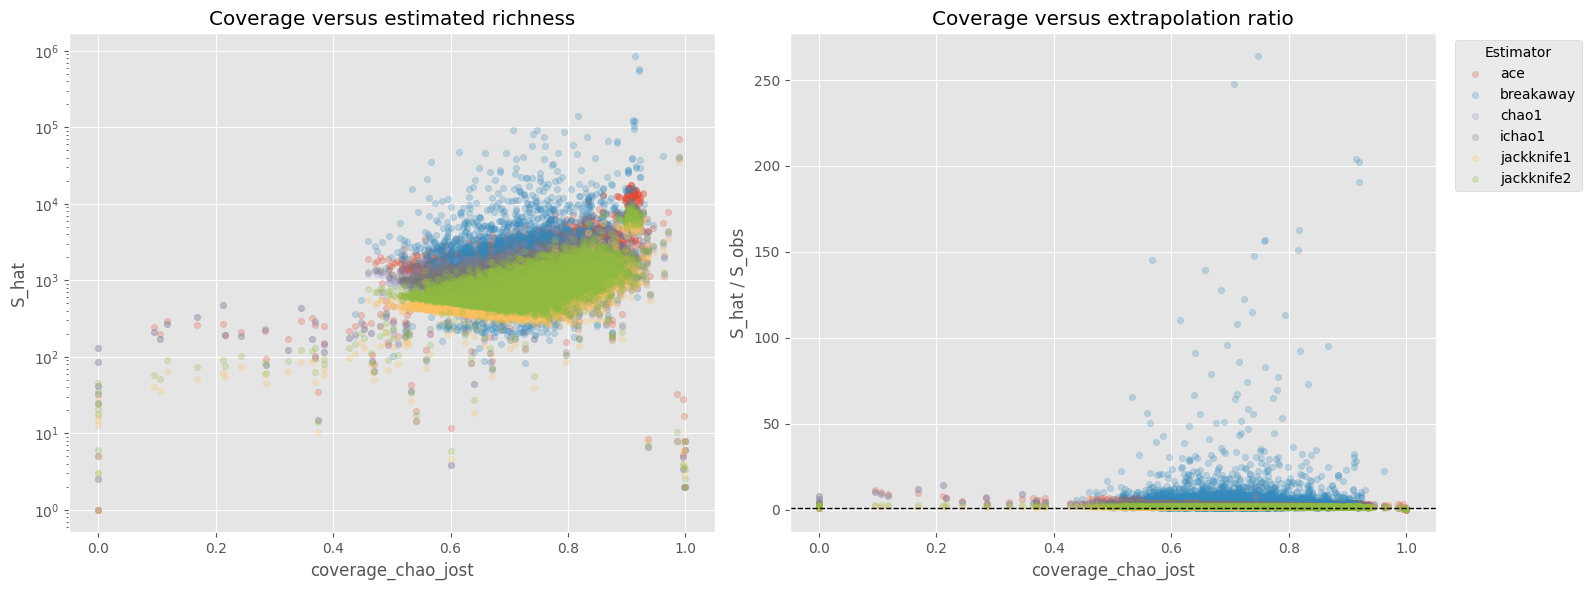

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for estimator_name, subset in estimates_long.groupby("estimator"):
    axes[0].scatter(subset["coverage_chao_jost"], subset["S_hat"], alpha=0.25, s=20, label=estimator_name)
    axes[1].scatter(subset["coverage_chao_jost"], subset["richness_ratio"], alpha=0.25, s=20, label=estimator_name)

axes[0].set_title("Coverage versus estimated richness")
axes[0].set_xlabel("coverage_chao_jost")
axes[0].set_ylabel("S_hat")
axes[0].set_yscale("log")

axes[1].set_title("Coverage versus extrapolation ratio")
axes[1].set_xlabel("coverage_chao_jost")
axes[1].set_ylabel("S_hat / S_obs")
axes[1].axhline(1.0, linestyle="--", color="black", linewidth=1)
axes[1].legend(title="Estimator", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Figure explanation.**

Coverage-based plots translate extrapolation into an interpretable measure of sample completeness. If richness ratios rise as coverage falls, the estimators are behaving in a conceptually expected way. If some methods extrapolate heavily even at high coverage, that behavior deserves special scrutiny.

When writing up the results, note whether estimator disagreement appears concentrated in low-coverage regions. That would support the view that estimator differences are most consequential precisely when the data are least complete.

## 9. Estimator Agreement And Disagreement

The next question is whether the estimators are broadly telling the same story or whether their outputs diverge in systematic ways.

Pairwise agreement plots are useful because they reveal both overall association and method-specific departures. Strong agreement suggests robust conclusions across methods; strong disagreement suggests that the substantive finding depends on estimator choice.

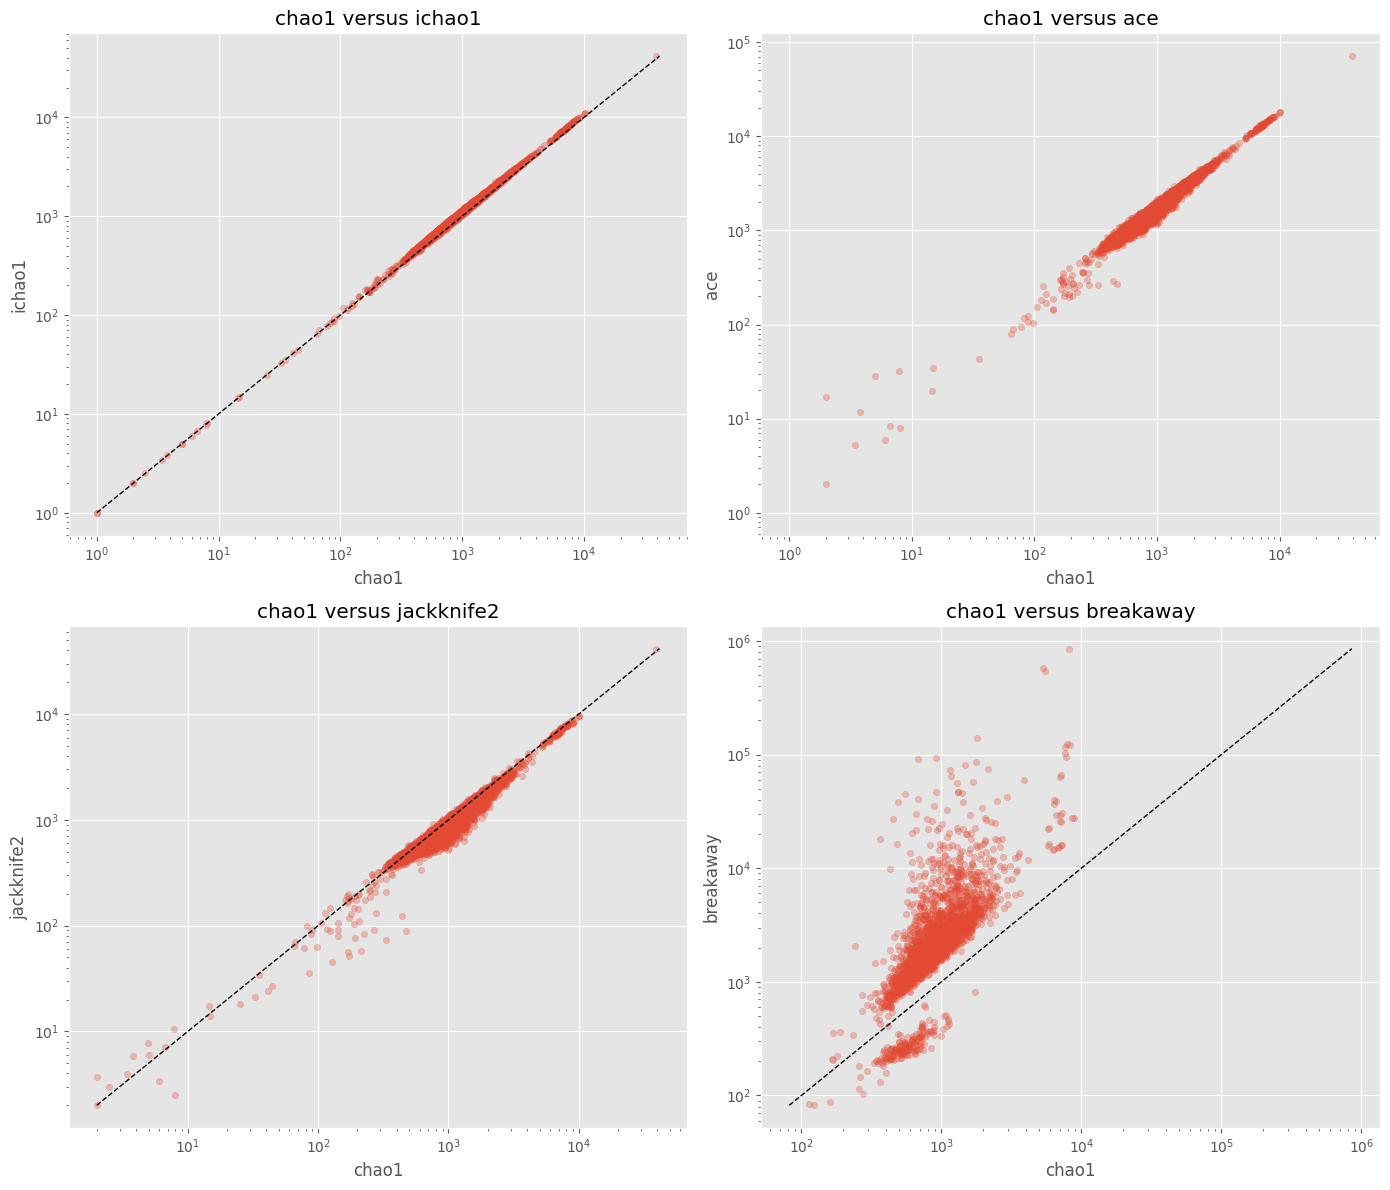

estimator,ace,breakaway,chao1,ichao1,jackknife1,jackknife2
estimator,,,,,,
ace,1.000,0.410,0.997,0.997,0.992,0.996
breakaway,0.410,1.000,0.411,0.411,0.412,0.413
chao1,0.997,0.411,1.000,1.000,0.987,0.992
ichao1,0.997,0.411,1.000,1.000,0.986,0.991
jackknife1,0.992,0.412,0.987,0.986,1.000,0.999
jackknife2,0.996,0.413,0.992,0.991,0.999,1.000


In [14]:
agreement_df = analysis_df[["id", "name", "corpus_source", "n_tokens", "s_obs", "coverage_chao_jost"]].merge(estimates_wide, left_on="id", right_index=True, how="left")

comparison_pairs = []
if "chao1" in agreement_df.columns and "ichao1" in agreement_df.columns:
    comparison_pairs.append(("chao1", "ichao1"))
if "chao1" in agreement_df.columns and "ace" in agreement_df.columns:
    comparison_pairs.append(("chao1", "ace"))
if "chao1" in agreement_df.columns and "jackknife2" in agreement_df.columns:
    comparison_pairs.append(("chao1", "jackknife2"))
if "chao1" in agreement_df.columns and "breakaway" in agreement_df.columns:
    comparison_pairs.append(("chao1", "breakaway"))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, pair in zip(axes.ravel(), comparison_pairs):
    x_name, y_name = pair
    subset = agreement_df[[x_name, y_name]].dropna()
    ax.scatter(subset[x_name], subset[y_name], alpha=0.3, s=20)
    mn = min(subset[x_name].min(), subset[y_name].min())
    mx = max(subset[x_name].max(), subset[y_name].max())
    ax.plot([mn, mx], [mn, mx], linestyle="--", color="black", linewidth=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_title(f"{x_name} versus {y_name}")

for ax in axes.ravel()[len(comparison_pairs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

agreement_summary = estimates_long.pivot_table(index="id", columns="estimator", values="S_hat")
display(agreement_summary.corr().round(3))

**Figure and table explanation.**

The pairwise scatter plots compare estimators directly on the same texts. Points near the identity line indicate strong agreement; persistent curvature or vertical spread around the line indicates systematic disagreement. The correlation table complements the scatter plots by summarizing global association across the full dataset.

Interpret these outputs together. High correlation alone does not guarantee agreement in magnitude, and visible deviations from the identity line can matter even when the overall association is strong.

## 10. Secondary Domain Comparison

This section is descriptive rather than central. The purpose is to show whether corpus source is associated with systematic differences in sample size, observed vocabulary, coverage, or estimated richness.

These figures should be interpreted cautiously because domain comparisons can be confounded by sample-size distribution and preprocessing differences. Still, they can provide useful context for the main estimator-focused analysis.

C:\Users\frato\AppData\Local\Temp\ipykernel_23688\475875884.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(token_groups, labels=token_labels, showfliers=False)
C:\Users\frato\AppData\Local\Temp\ipykernel_23688\475875884.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(obs_groups, labels=token_labels, showfliers=False)
C:\Users\frato\AppData\Local\Temp\ipykernel_23688\475875884.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(estimate_groups, labels=estimate_labels, showfliers=False)


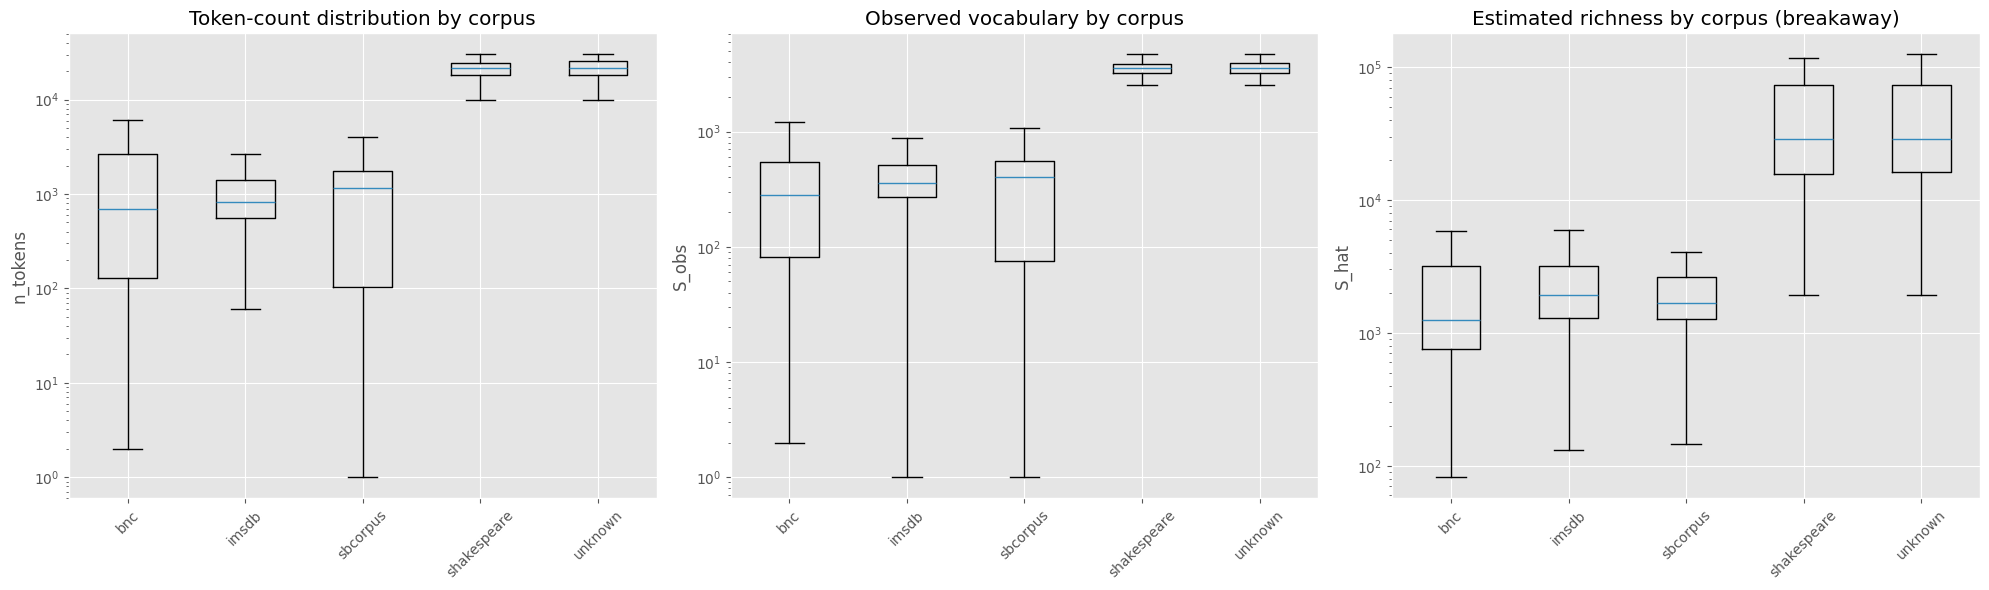

In [15]:
domain_focus = estimates_long.loc[estimates_long["estimator"].isin(focus_estimators)].copy()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

token_groups = [group["n_tokens"].values for _, group in analysis_df.groupby("corpus_source")]
token_labels = [label for label, _ in analysis_df.groupby("corpus_source")]
axes[0].boxplot(token_groups, labels=token_labels, showfliers=False)
axes[0].set_title("Token-count distribution by corpus")
axes[0].set_ylabel("n_tokens")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=45)

obs_groups = [group["s_obs"].values for _, group in analysis_df.groupby("corpus_source")]
axes[1].boxplot(obs_groups, labels=token_labels, showfliers=False)
axes[1].set_title("Observed vocabulary by corpus")
axes[1].set_ylabel("S_obs")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=45)

breakaway_or_chao = "breakaway" if "breakaway" in domain_focus["estimator"].unique() else "chao1"
domain_subset = domain_focus.loc[domain_focus["estimator"] == breakaway_or_chao]
estimate_groups = [group["S_hat"].values for _, group in domain_subset.groupby("corpus_source")]
estimate_labels = [label for label, _ in domain_subset.groupby("corpus_source")]
axes[2].boxplot(estimate_groups, labels=estimate_labels, showfliers=False)
axes[2].set_title(f"Estimated richness by corpus ({breakaway_or_chao})")
axes[2].set_ylabel("S_hat")
axes[2].set_yscale("log")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Figure explanation.**

These boxplots compare the broad empirical structure of the corpora. The first panel highlights whether the corpora differ strongly in sample size. The second shows whether observed vocabulary differs at the descriptive level. The third adds a representative richness estimator to show how domain differences may look after extrapolation.

Domain differences should be discussed as contextual patterns, not as the core result. If one corpus appears richer than another, the write-up should explicitly consider whether this is due to larger texts, lower coverage, or different low-frequency structure rather than to domain alone.

## 11. Real-Data Summary Tables

Because true vocabulary richness is unknown for the empirical corpora, the notebook summarizes estimator behavior descriptively rather than through strict error metrics.

The table below reports central tendency, spread, extrapolation intensity, and missing-output counts for each estimator. This is the appropriate style of summary for real data when no ground truth is available.

In [16]:
summary_table = (
    estimates_long.groupby("estimator")
    .agg(
        n_outputs=("S_hat", "size"),
        mean_S_hat=("S_hat", "mean"),
        median_S_hat=("S_hat", "median"),
        sd_S_hat=("S_hat", "std"),
        q25_S_hat=("S_hat", lambda x: x.quantile(0.25)),
        q75_S_hat=("S_hat", lambda x: x.quantile(0.75)),
        mean_f0_hat=("f0_hat", "mean"),
        median_ratio=("richness_ratio", "median"),
        mean_ratio=("richness_ratio", "mean")
    )
    .round(3)
    .sort_values("mean_S_hat")
)

failure_summary = (
    failures.groupby("estimator").size().rename("n_failures")
    if not failures.empty
    else pd.Series(dtype=int, name="n_failures")
)

display(summary_table)
if not failure_summary.empty:
    display(failure_summary)

,n_outputs,mean_S_hat,median_S_hat,sd_S_hat,q25_S_hat,q75_S_hat,mean_f0_hat,median_ratio,mean_ratio
estimator,,,,,,,,,
jackknife1,5600,771.654,590.756,829.151,452.673,849.615,290.632,1.634,1.629
jackknife2,5598,997.696,770.319,1026.592,594.362,1103.315,516.503,2.124,2.118
chao1,5600,1113.277,893.860,1041.424,677.007,1243.446,632.255,2.343,2.428
ichao1,5600,1218.408,977.425,1131.756,742.637,1363.267,737.386,2.565,2.656
breakaway,2782,4414.613,1941.990,23537.205,1291.589,3225.834,3970.723,5.234,8.074
ace,5603,inf,1532.915,NaN,1160.535,2186.938,inf,4.088,inf


estimator
breakaway     2821
chao1            3
ichao1           3
jackknife1       3
jackknife2       5
Name: n_failures, dtype: int64

**Table explanation.**

This summary table is a descriptive complement to the figures. The mean and median columns show central tendency, the standard deviation and quartiles show spread, and the ratio columns summarize how strongly each estimator extrapolates beyond observed vocabulary.

In the interpretation, compare not only average richness but also stability. A method with a high mean estimate but very large spread may behave aggressively or inconsistently across texts. If failures occur, they should be discussed explicitly as part of the estimator comparison.

## 12. Evaluation Strategy For True Error

This notebook does not compute RMSE, MAE, or other strict error metrics because the real corpora do not provide a known total vocabulary size. Without a reference truth or a carefully justified pseudo-truth, such error metrics would be methodologically misleading.

A later evaluation notebook should use one of the following designs:

- simulation from known frequency distributions so true richness is available
- subsampling from very large texts, treating the full sample as a practical reference
- incremental prediction experiments comparing early-sample estimates to later observed growth

Only in such settings does a table of bias, RMSE, MAE, or interval coverage become defensible.

## 13. Final Discussion Template

After running the notebook, the final write-up should synthesize the main findings around the following questions:

- Which estimator patterns are robust across sample sizes?
- Where do the estimators disagree most strongly?
- How much of the estimator behavior can be explained by singleton burden, rare-frequency mass, or low coverage?
- Do domain-level differences remain visible after accounting for sample size and coverage?
- Which practical lessons follow for vocabulary-richness estimation on real corpora?

The final text should also state the main limitations clearly:

- no known ground truth for true total vocabulary richness
- dependence on preprocessing and minimum-word filtering choices
- possible domain heterogeneity
- possible instability of some methods on sparse spectra

This notebook is intended to function as a self-contained analysis document. Before final submission, each figure interpretation should be updated with result-specific observations rather than remaining purely procedural.